# Fixed UPC-like toy generator notebook

This version fixes the original notebook by making process labels consistent, supporting both 2-body and 3-body final states in the same event table, avoiding invalid PID mappings, and adding an optional `exclude_processes` argument for anomaly-removal studies.

The generator remains a **toy generator**, not a STARlight/Pythia replacement: it is meant to create simple UPC-like samples for ML/debugging studies following the spirit of the JHEP workflow.

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

MASS = {
    "pi": 0.13957,
    "mu": 0.10566,
    "e": 0.000511,
    "p": 0.93827,
    "K": 0.49367,
    "rho": 0.77526,
    "rho_width": 0.1491,
    "Jpsi": 3.0969,
    "Psip": 3.6861,
    "Phi": 1.01946,
    "Pc": 4.360,
}

SPECIES_TO_PDG = {"e-": 11, "e+": -11, "mu-": 13, "mu+": -13, "K+": 321, "K-": -321, "p": 2212, "pbar": -2212}
PDG_TO_SPECIES = {v: k for k, v in SPECIES_TO_PDG.items()}
CHARGE_CONJ_MASS_KEY = {
    "e-": "e", "e+": "e",
    "mu-": "mu", "mu+": "mu",
    "K+": "K", "K-": "K",
    "p": "p", "pbar": "p",
}

PROCESS_CONFIG = {
    "Jpsi→mumu": {"parent_mass": MASS["Jpsi"], "daughters": ["mu+", "mu-"]},
    "Jpsi→ee":   {"parent_mass": MASS["Jpsi"], "daughters": ["e+", "e-"]},
    "Jpsi→pp":   {"parent_mass": MASS["Jpsi"], "daughters": ["p", "pbar"]},
    "Psip→mumu": {"parent_mass": MASS["Psip"], "daughters": ["mu+", "mu-"]},
    "Psip→ee":   {"parent_mass": MASS["Psip"], "daughters": ["e+", "e-"]},
    "Psip→pp":   {"parent_mass": MASS["Psip"], "daughters": ["p", "pbar"]},
    "Phi→KK":    {"parent_mass": MASS["Phi"],  "daughters": ["K+", "K-"]},
    "X→pp":      {"parent_mass": 3.0*MASS["p"], "daughters": ["p", "pbar"]},
    "γγ→mumu":   {"continuum": True, "mass_range": (2*MASS["mu"], 4.0), "daughters": ["mu+", "mu-"]},
    "γγ→ee":     {"continuum": True, "mass_range": (2*MASS["e"], 4.0),  "daughters": ["e+", "e-"]},
    "γγ→pp":     {"continuum": True, "mass_range": (2*MASS["p"], 5.0),  "daughters": ["p", "pbar"]},
    "Pc→p+mumu": {"parent_mass": MASS["Pc"], "daughters": ["p", "mu+", "mu-"]},
}

HYPOTHESIS_MASSES = {"e": MASS["e"], "mu": MASS["mu"], "K": MASS["K"], "p": MASS["p"]}


/home/student/Pulpit/valeriia/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def eta_from_p(px, py, pz):
    p = np.sqrt(px*px + py*py + pz*pz)
    return 0.5*np.log((p + pz + 1e-12)/(p - pz + 1e-12))


def rapidity(E, pz):
    return 0.5*np.log((E + pz + 1e-12)/(E - pz + 1e-12))


def daughter_mass(species: str) -> float:
    return MASS[CHARGE_CONJ_MASS_KEY[species]]


def bethe_bloch(beta_gamma):
    """Simple Bethe-Bloch-like toy parametrisation, not an ALICE calibration."""
    beta_gamma = np.asarray(beta_gamma, dtype=float)
    beta_gamma = np.clip(beta_gamma, 1e-4, None)
    K, B, C, D = 15.0, 2.0, 1.5, 12.0
    return K/(beta_gamma**B) + C*np.log(beta_gamma) + D


def two_body_momentum(M, m1, m2):
    M = np.asarray(M, dtype=float)
    arg = (M**2 - (m1 + m2)**2) * (M**2 - (m1 - m2)**2)
    return np.sqrt(np.maximum(arg, 0.0))/(2*M)


def random_unit_vectors(n):
    costh = rng.uniform(-1.0, 1.0, n)
    sinth = np.sqrt(1.0 - costh*costh)
    phi = rng.uniform(0.0, 2.0*np.pi, n)
    return sinth*np.cos(phi), sinth*np.sin(phi), costh


def lorentz_boost(px, py, pz, E, bx, by, bz):
    """Boost four-vectors by velocity beta=(bx,by,bz). Works with scalars/arrays."""
    b2 = bx*bx + by*by + bz*bz
    b2 = np.asarray(b2)
    gamma = 1.0/np.sqrt(np.maximum(1.0 - b2, 1e-12))
    bp = bx*px + by*py + bz*pz
    gamma2 = np.where(b2 > 0, (gamma - 1.0)/b2, 0.0)
    pxp = px + gamma2*bp*bx + gamma*bx*E
    pyp = py + gamma2*bp*by + gamma*by*E
    pzp = pz + gamma2*bp*bz + gamma*bz*E
    Ep = gamma*(E + bp)
    return pxp, pyp, pzp, Ep


In [3]:
def generate_two_body_process(n, label, parent_mass, daughters):
    m1, m2 = [daughter_mass(x) for x in daughters]
    M = np.full(n, parent_mass, dtype=float)
    pstar = two_body_momentum(M, m1, m2)
    ux, uy, uz = random_unit_vectors(n)
    rows = []
    for i in range(n):
        rows.append({
            "process": label, "n_tracks": 2, "parent_mass": M[i],
            "px1": pstar[i]*ux[i],  "py1": pstar[i]*uy[i],  "pz1": pstar[i]*uz[i],  "species1": daughters[0],
            "px2": -pstar[i]*ux[i], "py2": -pstar[i]*uy[i], "pz2": -pstar[i]*uz[i], "species2": daughters[1],
            "px3": np.nan, "py3": np.nan, "pz3": np.nan, "species3": None,
        })
    return pd.DataFrame(rows)


def generate_gamma_gamma_process(n, label, mass_range, daughters):
    m1, m2 = [daughter_mass(x) for x in daughters]
    lo = max(mass_range[0], m1 + m2 + 1e-6)
    hi = mass_range[1]
    M = rng.uniform(lo, hi, n)
    pstar = two_body_momentum(M, m1, m2)
    ux, uy, uz = random_unit_vectors(n)
    rows = []
    for i in range(n):
        rows.append({
            "process": label, "n_tracks": 2, "parent_mass": M[i],
            "px1": pstar[i]*ux[i],  "py1": pstar[i]*uy[i],  "pz1": pstar[i]*uz[i],  "species1": daughters[0],
            "px2": -pstar[i]*ux[i], "py2": -pstar[i]*uy[i], "pz2": -pstar[i]*uz[i], "species2": daughters[1],
            "px3": np.nan, "py3": np.nan, "pz3": np.nan, "species3": None,
        })
    return pd.DataFrame(rows)


def generate_pc_to_p_mumu(n, label="Pc→p+mumu"):
    """Toy sequential 3-body decay: Pc -> p + X, X -> mu+ mu-."""
    M = MASS["Pc"]
    mp, mmu = MASS["p"], MASS["mu"]
    rows = []
    for _ in range(n):
        mX = rng.uniform(2*mmu + 1e-6, M - mp - 1e-6)
        p_p = two_body_momentum(M, mp, mX).item()
        ux, uy, uz = random_unit_vectors(1)
        ux, uy, uz = ux[0], uy[0], uz[0]
        pxp, pyp, pzp = p_p*ux, p_p*uy, p_p*uz
        Ep = np.sqrt(p_p*p_p + mp*mp)
        pxX, pyX, pzX = -pxp, -pyp, -pzp
        EX = np.sqrt(p_p*p_p + mX*mX)

        # X rest-frame muons
        p_mu = two_body_momentum(mX, mmu, mmu).item()
        vx, vy, vz = random_unit_vectors(1)
        vx, vy, vz = vx[0], vy[0], vz[0]
        px1, py1, pz1 = p_mu*vx, p_mu*vy, p_mu*vz
        E_mu = np.sqrt(p_mu*p_mu + mmu*mmu)
        px2, py2, pz2 = -px1, -py1, -pz1

        # boost muons from X rest frame to Pc rest frame
        bx, by, bz = pxX/EX, pyX/EX, pzX/EX
        pxm1, pym1, pzm1, _ = lorentz_boost(px1, py1, pz1, E_mu, bx, by, bz)
        pxm2, pym2, pzm2, _ = lorentz_boost(px2, py2, pz2, E_mu, bx, by, bz)

        rows.append({
            "process": label, "n_tracks": 3, "parent_mass": M,
            "px1": pxp,  "py1": pyp,  "pz1": pzp,  "species1": "p",
            "px2": pxm1, "py2": pym1, "pz2": pzm1, "species2": "mu+",
            "px3": pxm2, "py3": pym2, "pz3": pzm2, "species3": "mu-",
        })
    return pd.DataFrame(rows)


In [4]:
def add_derived_track_columns(df):
    df = df.copy()
    for i in (1, 2, 3):
        has = df[f"species{i}"].notna()
        px, py, pz = df[f"px{i}"], df[f"py{i}"], df[f"pz{i}"]
        p = np.sqrt(px*px + py*py + pz*pz)
        df[f"p{i}"] = np.where(has, p, np.nan)
        df[f"pt{i}"] = np.where(has, np.sqrt(px*px + py*py), np.nan)
        df[f"eta{i}"] = np.where(has, eta_from_p(px, py, pz), np.nan)
    return df


def smear_momenta(df, a=0.005, b=0.010):
    """Toy ALICE-like relative momentum smearing: sigma(p)/p = sqrt(a^2 + (b p)^2)."""
    df = df.copy()
    for i in (1, 2, 3):
        mask = df[f"species{i}"].notna()
        p = np.sqrt(df[f"px{i}"]**2 + df[f"py{i}"]**2 + df[f"pz{i}"]**2)
        sigma_rel = np.sqrt(a*a + (b*p)**2)
        scale = rng.normal(1.0, sigma_rel)
        for comp in ("px", "py", "pz"):
            df.loc[mask, f"{comp}{i}"] = df.loc[mask, f"{comp}{i}"] * scale[mask]
    return add_derived_track_columns(df)


def add_pid_response(df, rel_resolution=0.06):
    df = df.copy()
    for i in (1, 2, 3):
        mask = df[f"species{i}"].notna()
        mass = df[f"species{i}"].map(lambda s: daughter_mass(s) if pd.notna(s) else np.nan)
        p = np.sqrt(df[f"px{i}"]**2 + df[f"py{i}"]**2 + df[f"pz{i}"]**2)
        expected = bethe_bloch(p/mass)
        measured = expected * rng.normal(1.0, rel_resolution, len(df))
        df[f"dedx{i}"] = np.where(mask, measured, np.nan)
    return df


def generate_all(n_per_process=3000, include_processes=None, apply_smearing=True, seed=42):
    global rng
    rng = np.random.default_rng(seed)
    include_processes = list(PROCESS_CONFIG) if include_processes is None else include_processes
    frames = []
    for label in include_processes:
        cfg = PROCESS_CONFIG[label]
        if label == "Pc→p+mumu":
            frames.append(generate_pc_to_p_mumu(n_per_process, label))
        elif cfg.get("continuum", False):
            frames.append(generate_gamma_gamma_process(n_per_process, label, cfg["mass_range"], cfg["daughters"]))
        else:
            frames.append(generate_two_body_process(n_per_process, label, cfg["parent_mass"], cfg["daughters"]))
    df = pd.concat(frames, ignore_index=True)
    if apply_smearing:
        df = smear_momenta(df)
    else:
        df = add_derived_track_columns(df)
    df = add_pid_response(df)
    df.insert(0, "EventID", np.arange(len(df), dtype=int))
    return df


def apply_acceptance(df, eta_max=0.9):
    """Require all reconstructed tracks in the event to be inside |eta| < eta_max."""
    masks = []
    for i in (1, 2, 3):
        present = df[f"species{i}"].notna()
        in_acc = df[f"eta{i}"].abs() < eta_max
        masks.append((~present) | in_acc)
    return df[masks[0] & masks[1] & masks[2]].copy()


In [5]:
def invariant_mass_for_event(row):
    E, px, py, pz = 0.0, 0.0, 0.0, 0.0
    for i in (1, 2, 3):
        species = row.get(f"species{i}")
        if pd.isna(species):
            continue
        mi = daughter_mass(species)
        pxi, pyi, pzi = row[f"px{i}"], row[f"py{i}"], row[f"pz{i}"]
        E += np.sqrt(pxi*pxi + pyi*pyi + pzi*pzi + mi*mi)
        px += pxi; py += pyi; pz += pzi
    return np.sqrt(max(E*E - px*px - py*py - pz*pz, 0.0))


def build_track_table(df, exclude_processes=None):
    exclude_processes = set(exclude_processes or [])
    rows = []
    for _, ev in df.iterrows():
        if ev["process"] in exclude_processes:
            continue
        for i in (1, 2, 3):
            species = ev[f"species{i}"]
            if pd.isna(species):
                continue
            px, py, pz = ev[f"px{i}"], ev[f"py{i}"], ev[f"pz{i}"]
            p = np.sqrt(px*px + py*py + pz*pz)
            true_key = CHARGE_CONJ_MASS_KEY[species]
            true_mass = MASS[true_key]
            dedx_meas = ev[f"dedx{i}"]
            entry = {
                "EventID": int(ev["EventID"]),
                "process": ev["process"],
                "TrackID": i,
                "species": species,
                "mass_true": true_mass,
                "px": px, "py": py, "pz": pz,
                "p": p, "pt": np.sqrt(px*px + py*py), "eta": eta_from_p(px, py, pz),
                "E_true": np.sqrt(p*p + true_mass*true_mass),
                "dedx": dedx_meas,
            }
            for name, mass_hyp in HYPOTHESIS_MASSES.items():
                expected = bethe_bloch(p/mass_hyp)
                sigma = 0.06*expected
                entry[f"N_sigma_{name}"] = (dedx_meas - expected)/sigma
            rows.append(entry)
    return pd.DataFrame(rows)


def build_event_table(df, track_table=None, nsigma_ref=3.0, exclude_processes=None):
    exclude_processes = set(exclude_processes or [])
    base = df[~df["process"].isin(exclude_processes)].copy()
    if track_table is None:
        track_table = build_track_table(base)
    tmp = track_table.copy()
    for sp in ["e", "mu", "K", "p"]:
        tmp[f"pass_{sp}"] = (tmp[f"N_sigma_{sp}"].abs() < nsigma_ref).astype(int)
    counts = tmp.groupby("EventID").agg(
        N_tracks=("TrackID", "count"),
        N_e=("pass_e", "sum"), N_mu=("pass_mu", "sum"),
        N_K=("pass_K", "sum"), N_p=("pass_p", "sum"),
    ).reset_index()
    event_features = base[["EventID", "process", "n_tracks", "parent_mass"]].copy()
    event_features["M_reco"] = base.apply(invariant_mass_for_event, axis=1)
    return event_features.merge(counts, on="EventID", how="left")


def first(df, exclude_processes=None):
    """Backwards-compatible name: return a track-level ML feature table."""
    return build_track_table(df, exclude_processes=exclude_processes)


def second(df, exclude_processes=None, nsigma_ref=3.0):
    """Backwards-compatible name: return an event-level ML feature table."""
    tr = build_track_table(df, exclude_processes=exclude_processes)
    return build_event_table(df, tr, nsigma_ref=nsigma_ref, exclude_processes=exclude_processes)


In [6]:
def QA(df, max_points_per_process=1500):
    processes = df["process"].unique()
    
    plt.figure(figsize=(8, 5))
    for proc in processes:
        sub = df[df["process"] == proc]
        vals = pd.concat([sub[f"pt{i}"].dropna() for i in (1, 2, 3)])
        plt.hist(vals, bins=80, histtype="step", label=proc)
    plt.xlabel(r"$p_T$ (GeV/$c$)")
    plt.ylabel("Tracks")
    plt.yscale("log")
    plt.title("Track transverse momentum")
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    for proc in processes:
        sub = df[df["process"] == proc]
        M = sub.apply(invariant_mass_for_event, axis=1)
        plt.hist(M, bins=100, histtype="step", label=proc)
    plt.xlabel(r"Reconstructed invariant mass (GeV/$c^2$)")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.title("Invariant-mass QA")
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    track_df = build_track_table(df)
    plt.figure(figsize=(8, 6))
    for proc in processes:
        sub = track_df[track_df["process"] == proc].sample(min(max_points_per_process, (track_df["process"] == proc).sum()), random_state=1)
        plt.scatter(sub["p"], sub["dedx"], s=2, alpha=0.25, label=proc)
    p_ref = np.logspace(-2, 1, 400)
    for sp, mass in HYPOTHESIS_MASSES.items():
        plt.plot(p_ref, bethe_bloch(p_ref/mass), linewidth=1.2, label=f"{sp} hypothesis")
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel(r"$p$ (GeV/$c$)")
    plt.ylabel("toy dE/dx")
    plt.title("PID QA")
    plt.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()


process
Jpsi→mumu    2000
Jpsi→ee      2000
Jpsi→pp      2000
Psip→mumu    2000
Psip→ee      2000
Psip→pp      2000
Phi→KK       2000
X→pp         2000
γγ→mumu      2000
γγ→ee        2000
γγ→pp        2000
Pc→p+mumu    2000
Name: count, dtype: int64
Total events: 24000
Events after |eta| < 0.9 for all final-state tracks: 16735


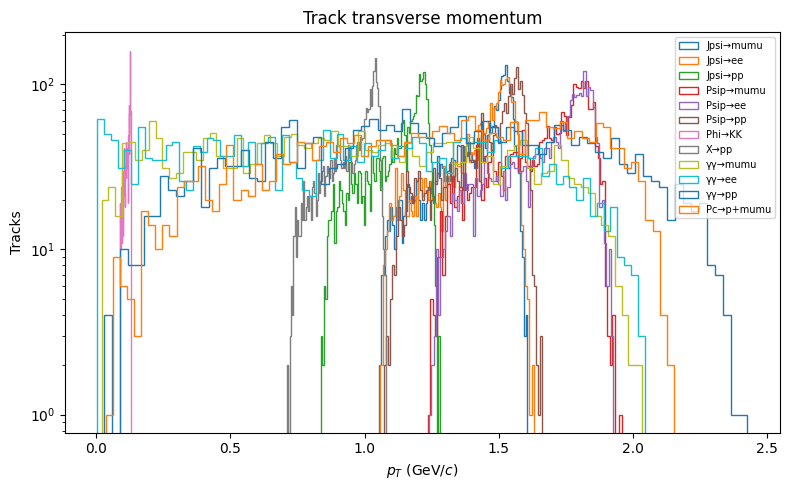

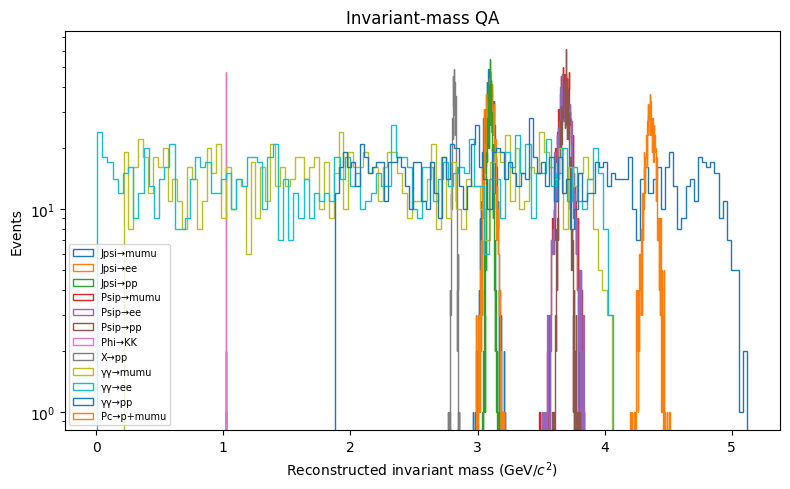

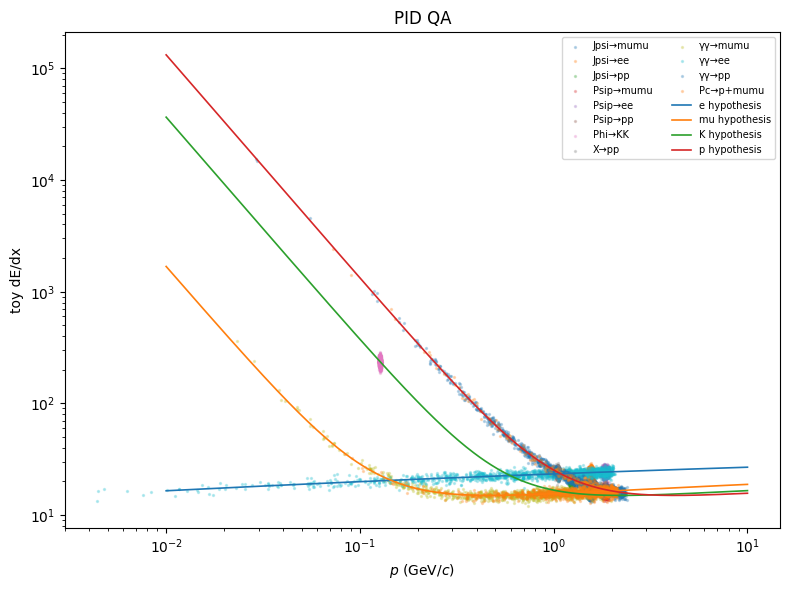

In [7]:
# Demo run. Increase n_per_process when you need larger training samples.
df = generate_all(n_per_process=2000, seed=123)
print(df["process"].value_counts())
print("Total events:", len(df))

df_acc = apply_acceptance(df, eta_max=0.9)
print("Events after |eta| < 0.9 for all final-state tracks:", len(df_acc))

QA(df_acc)


In [8]:
track_table = build_track_table(df_acc)
event_table = build_event_table(df_acc, track_table=track_table, nsigma_ref=3.0)

# Example: remove obvious injected anomalies from the training/reference sample.
df_without_anomalies = df_acc[~df_acc["process"].isin(["Jpsi→pp", "Pc→p+mumu"])].copy()
first_set_without_anomalies = first(df_acc, exclude_processes=["Jpsi→pp", "Pc→p+mumu"])
second_set_without_anomalies = second(df_acc, exclude_processes=["Jpsi→pp", "Pc→p+mumu"], nsigma_ref=3.0)

print("Track table")
display(track_table.head())
print("Event table")
display(event_table.head())
print("Track table without anomalies")
display(first_set_without_anomalies.head())
print("Event table without anomalies")
display(second_set_without_anomalies.head())

track_table.to_csv("track_based_table.csv", index=False)
event_table.to_csv("event_based_table.csv", index=False)
first_set_without_anomalies.to_csv("track_based_table_without_anomalies.csv", index=False)
second_set_without_anomalies.to_csv("event_based_table_without_anomalies.csv", index=False)


Track table


,EventID,process,TrackID,species,mass_true,px,py,pz,p,pt,eta,E_true,dedx,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,0,Jpsi→mumu,1,mu+,0.10566,-0.827871,1.174528,0.562835,1.543266,1.436972,0.382301,1.546879,15.151812,-6.153146,-0.974209,-0.101437,-2.860385
1,0,Jpsi→mumu,2,mu-,0.10566,0.853488,-1.210872,-0.580251,1.591020,1.481436,-0.382301,1.594524,15.978217,-5.600780,-0.160937,0.853828,-1.879282
2,2,Jpsi→mumu,1,mu+,0.10566,1.245843,-0.328749,-0.869293,1.554307,1.288487,-0.631785,1.557894,18.033017,-4.159506,1.998555,3.062820,-0.173909
3,2,Jpsi→mumu,2,mu-,0.10566,-1.259797,0.332431,0.879030,1.571716,1.302919,0.631785,1.575263,17.478692,-4.552392,1.407756,2.477242,-0.589390
4,3,Jpsi→mumu,1,mu+,0.10566,0.153799,1.185789,-0.973223,1.541724,1.195721,-0.743502,1.545340,15.578697,-5.856264,-0.530729,0.363513,-2.478854


Event table


,EventID,process,n_tracks,parent_mass,M_reco,N_tracks,N_e,N_mu,N_K,N_p
0,0,Jpsi→mumu,2,3.0969,3.141040,2,0,2,2,2
1,2,Jpsi→mumu,2,3.0969,3.133109,2,0,2,1,2
2,3,Jpsi→mumu,2,3.0969,3.066463,2,0,2,2,2
3,4,Jpsi→mumu,2,3.0969,3.081439,2,0,2,2,2
4,5,Jpsi→mumu,2,3.0969,3.122277,2,0,2,2,2


Track table without anomalies


,EventID,process,TrackID,species,mass_true,px,py,pz,p,pt,eta,E_true,dedx,N_sigma_e,N_sigma_mu,N_sigma_K,N_sigma_p
0,0,Jpsi→mumu,1,mu+,0.10566,-0.827871,1.174528,0.562835,1.543266,1.436972,0.382301,1.546879,15.151812,-6.153146,-0.974209,-0.101437,-2.860385
1,0,Jpsi→mumu,2,mu-,0.10566,0.853488,-1.210872,-0.580251,1.591020,1.481436,-0.382301,1.594524,15.978217,-5.600780,-0.160937,0.853828,-1.879282
2,2,Jpsi→mumu,1,mu+,0.10566,1.245843,-0.328749,-0.869293,1.554307,1.288487,-0.631785,1.557894,18.033017,-4.159506,1.998555,3.062820,-0.173909
3,2,Jpsi→mumu,2,mu-,0.10566,-1.259797,0.332431,0.879030,1.571716,1.302919,0.631785,1.575263,17.478692,-4.552392,1.407756,2.477242,-0.589390
4,3,Jpsi→mumu,1,mu+,0.10566,0.153799,1.185789,-0.973223,1.541724,1.195721,-0.743502,1.545340,15.578697,-5.856264,-0.530729,0.363513,-2.478854


Event table without anomalies


,EventID,process,n_tracks,parent_mass,M_reco,N_tracks,N_e,N_mu,N_K,N_p
0,0,Jpsi→mumu,2,3.0969,3.141040,2,0,2,2,2
1,2,Jpsi→mumu,2,3.0969,3.133109,2,0,2,1,2
2,3,Jpsi→mumu,2,3.0969,3.066463,2,0,2,2,2
3,4,Jpsi→mumu,2,3.0969,3.081439,2,0,2,2,2
4,5,Jpsi→mumu,2,3.0969,3.122277,2,0,2,2,2


## What was fixed compared with the uploaded version

1. **Consistent labels**: the notebook now uses one pentaquark label everywhere: `Pc→p+mumu`.
2. **The final crash is fixed**: `first(df, exclude_processes=[...])` now works.
3. **3-body events are supported properly**: tables no longer assume every event has only two tracks.
4. **PID mapping is done track-by-track**: a `Pc→p+mumu` event has one proton and two muons, not three protons.
5. **Invariant mass is event-level and uses the true generated daughter masses**, rather than assigning the pion mass to every track.
6. **The demo uses a smaller default sample** so the notebook runs quickly; increase `n_per_process` for production studies.
